# Import all the required libraries

---



In [3]:
import pandas as pd
import datetime as dt
from datetime import date
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np
import tensorflow as tf
from ta.trend import SMAIndicator
from ta.momentum import RSIIndicator
from ta.volatility import BollingerBands

Loading Data Set

---

In [7]:

df = pd.read_csv('NSE_WIPRO.csv')
# Example: assuming your date column is named 'Date'
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y').dt.strftime('%Y-%m-%d')
data=df
df.head()
df['SMA'] = SMAIndicator(close=df['Close'], window=14).sma_indicator()
df['RSI'] = RSIIndicator(close=df['Close'], window=14).rsi()
# df['VWAP'] = (df['Close'] * df['Volume']).cumsum() / df['Volume'].cumsum()
bb = BollingerBands(close=df['Close'], window=20, window_dev=2)
df['BB_upper'] = bb.bollinger_hband()
df['BB_lower'] = bb.bollinger_lband()
df.dropna(inplace=True)


In [8]:
# df = df.drop(['Date', 'Adj Close'], axis = 1)
df.head()

,Date,Open,High,Low,Close,SMA,RSI,BB_upper,BB_lower
19,1996-01-26,0.415574,0.415574,0.415574,0.415574,0.420281,36.637735,0.436757,0.407412
20,1996-01-29,0.410627,0.416069,0.410627,0.415574,0.419574,36.637735,0.430971,0.410230
21,1996-01-30,0.415574,0.415574,0.395834,0.412160,0.418581,33.486580,0.430770,0.410584
22,1996-01-31,0.412160,0.412160,0.412160,0.412160,0.417631,33.486580,0.430501,0.409523
23,1996-02-01,0.412160,0.412160,0.412160,0.412160,0.416680,33.486580,0.430052,0.408640


Visualizing Closing Price

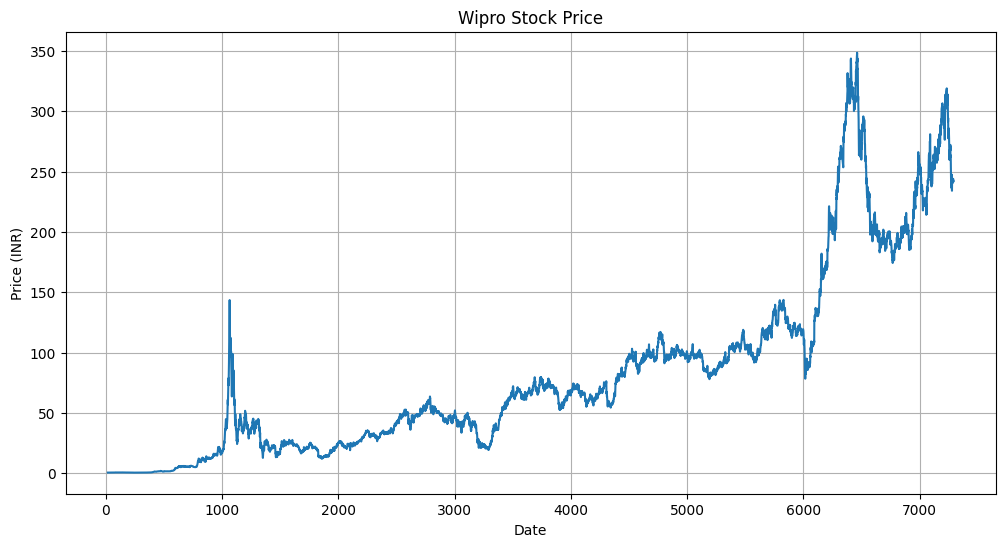

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'])
plt.title("Wipro Stock Price")
plt.xlabel("Date")
plt.ylabel("Price (INR)")
plt.grid(True)
plt.show()

In [10]:
df

,Date,Open,High,Low,Close,SMA,RSI,BB_upper,BB_lower
19,1996-01-26,0.415574,0.415574,0.415574,0.415574,0.420281,36.637735,0.436757,0.407412
20,1996-01-29,0.410627,0.416069,0.410627,0.415574,0.419574,36.637735,0.430971,0.410230
21,1996-01-30,0.415574,0.415574,0.395834,0.412160,0.418581,33.486580,0.430770,0.410584
22,1996-01-31,0.412160,0.412160,0.412160,0.412160,0.417631,33.486580,0.430501,0.409523
23,1996-02-01,0.412160,0.412160,0.412160,0.412160,0.416680,33.486580,0.430052,0.408640
...,...,...,...,...,...,...,...,...,...
7287,2025-05-05,244.000000,246.870000,242.700000,243.570000,241.285000,42.435927,256.601350,230.502650
7288,2025-05-06,244.500000,245.900000,240.610000,241.190000,241.387857,40.287029,251.704839,233.158161
7289,2025-05-07,236.010000,244.450000,236.010000,244.040000,241.390714,43.947443,248.616881,235.015119
7290,2025-05-08,243.110000,245.830000,239.310000,241.570000,240.956429,41.569129,248.061714,235.097286


In [11]:
df.shape

(7273, 9)

# Spliting the dataset into training (70%) and testing (30%) set

In [1]:
# Splitting data into training and testing

train = pd.DataFrame(data[0:int(len(data)*0.70)])
test = pd.DataFrame(data[int(len(data)*0.70): int(len(data))])

print(train.shape)
print(test.shape)

NameError: name 'pd' is not defined

In [13]:
train.head()

,Date,Open,High,Low,Close,SMA,RSI,BB_upper,BB_lower
19,1996-01-26,0.415574,0.415574,0.415574,0.415574,0.420281,36.637735,0.436757,0.407412
20,1996-01-29,0.410627,0.416069,0.410627,0.415574,0.419574,36.637735,0.430971,0.410230
21,1996-01-30,0.415574,0.415574,0.395834,0.412160,0.418581,33.486580,0.430770,0.410584
22,1996-01-31,0.412160,0.412160,0.412160,0.412160,0.417631,33.486580,0.430501,0.409523
23,1996-02-01,0.412160,0.412160,0.412160,0.412160,0.416680,33.486580,0.430052,0.408640


In [14]:
test.head()

,Date,Open,High,Low,Close,SMA,RSI,BB_upper,BB_lower
5110,2016-07-15,101.550002,102.440948,98.574242,98.805886,99.779313,47.898912,102.474808,96.840668
5111,2016-07-18,98.627697,98.707884,97.077449,98.351505,99.842006,46.079826,102.467119,96.864090
5112,2016-07-19,97.113089,98.672244,96.934900,97.870393,99.941483,44.167162,102.505044,96.704850
5113,2016-07-20,92.301982,96.444880,92.301982,96.017222,99.754223,37.679523,102.708356,96.124648
5114,2016-07-21,96.026139,97.077449,96.026139,96.578521,99.563859,40.528944,102.730583,95.743416


# Using MinMax scaler for normalization of the dataset

---



In [15]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [20]:
features = ['Close', 'SMA', 'RSI', 'BB_upper', 'BB_lower']
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[features])
# train_close = train.iloc[:, 4:5].values
# test_close = test.iloc[:, 4:5].values

In [21]:
train_close

array([[  0.41557399],
       [  0.41557399],
       [  0.41216035],
       ...,
       [101.7103673 ],
       [102.2716667 ],
       [101.6747277 ]])

In [22]:
test_close

array([[ 98.80588589],
       [ 98.35150533],
       [ 97.87039283],
       ...,
       [244.04      ],
       [241.57      ],
       [242.01      ]])

In [23]:
data_training_array = scaler.fit_transform(train_close)
data_training_array

array([[0.00077085],
       [0.00077085],
       [0.00074701],
       ...,
       [0.70824665],
       [0.71216695],
       [0.70799773]])

In [24]:
x_train = []
y_train = [] 

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100: i])
    y_train.append(data_training_array[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train) 

In [25]:
x_train.shape

(4991, 100, 1)

## Model (LSTM)

---



In [26]:
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.models import Sequential

In [27]:
model = Sequential()
model.add(LSTM(units = 60, activation = 'relu', return_sequences=True
              ,input_shape = (x_train.shape[1], 1)))
model.add(Dropout(0.2))


model.add(LSTM(units = 70, activation = 'relu', return_sequences=True))
model.add(Dropout(0.3))


model.add(LSTM(units = 90, activation = 'relu', return_sequences=True))
model.add(Dropout(0.4))


model.add(LSTM(units = 120, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units = 1))

In [23]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 100, 60)           14880     
                                                                 
 dropout (Dropout)           (None, 100, 60)           0         
                                                                 
 lstm_1 (LSTM)               (None, 100, 70)           36680     
                                                                 
 dropout_1 (Dropout)         (None, 100, 70)           0         
                                                                 
 lstm_2 (LSTM)               (None, 100, 90)           57960     
                                                                 
 dropout_2 (Dropout)         (None, 100, 90)           0         
                                                                 
 lstm_3 (LSTM)               (None, 120)               1

# Training the model

---



In [28]:
import tensorflow as tf
model.compile(optimizer = 'adam', loss = 'mean_squared_error', metrics=[tf.keras.metrics.MeanAbsoluteError()])
model.fit(x_train, y_train,epochs = 10)

Epoch 1/10
156/156 [==============================] - 100s 506ms/step - loss: 0.0129 - mean_absolute_error: 0.0723
Epoch 2/10
156/156 [==============================] - 75s 479ms/step - loss: 0.0050 - mean_absolute_error: 0.0483
Epoch 3/10
156/156 [==============================] - 74s 474ms/step - loss: 0.0042 - mean_absolute_error: 0.0441
Epoch 4/10
156/156 [==============================] - 76s 485ms/step - loss: 0.0036 - mean_absolute_error: 0.0418
Epoch 5/10
156/156 [==============================] - 75s 481ms/step - loss: 0.0036 - mean_absolute_error: 0.0414
Epoch 6/10
156/156 [==============================] - 74s 472ms/step - loss: 0.0030 - mean_absolute_error: 0.0377
Epoch 7/10
156/156 [==============================] - 76s 485ms/step - loss: 0.0028 - mean_absolute_error: 0.0365
Epoch 8/10
156/156 [==============================] - 71s 456ms/step - loss: 0.0025 - mean_absolute_error: 0.0346
Epoch 9/10
156/156 [==============================] - 71s 457ms/step - loss: 0.0023 - m

In [29]:
model.save('keras_model.h5')

In [30]:
test_close.shape

(2182, 1)

In [31]:
past_100_days = pd.DataFrame(train_close[-100:])

In [32]:
test_df = pd.DataFrame(test_close)

**Defining the final dataset for testing by including last 100 coloums of the training dataset to get the prediction from the 1st column of the testing dataset.**

---


In [33]:
# final_df = past_100_days.append(test_df, ignore_index = True)
final_df = pd.concat([past_100_days, test_df], ignore_index=True)

In [34]:
final_df.head()

,0
0,93.729596
1,96.282054
2,97.358177
3,96.539970
4,96.041931


In [35]:
input_data = scaler.fit_transform(final_df)
input_data

array([[0.05848682],
       [0.06791484],
       [0.07188972],
       ...,
       [0.61368842],
       [0.60456498],
       [0.60619021]])

In [36]:
input_data.shape

(2282, 1)

# Testing the model

---



In [37]:
x_test = []
y_test = []
for i in range(100, input_data.shape[0]):
   x_test.append(input_data[i-100: i])
   y_test.append(input_data[i, 0])

In [38]:
x_test, y_test = np.array(x_test), np.array(y_test)
print(x_test.shape)
print(y_test.shape)

(2182, 100, 1)
(2182,)


# Making prediction and plotting the graph of predicted vs actual values

---



In [39]:
# Making predictions

y_pred = model.predict(x_test)

69/69 [==============================] - 13s 170ms/step


In [40]:
y_pred.shape

(2182, 1)

In [41]:
y_test

array([0.07723712, 0.07555877, 0.07378169, ..., 0.61368842, 0.60456498,
       0.60619021])

In [42]:
y_pred

array([[0.07385261],
       [0.07442822],
       [0.07501827],
       ...,
       [0.5729352 ],
       [0.575549  ],
       [0.57774097]], dtype=float32)

In [43]:
scaler.scale_

array([0.0036937])

In [44]:
scale_factor = 1/0.00041967
y_pred = y_pred * scale_factor
y_test = y_test * scale_factor

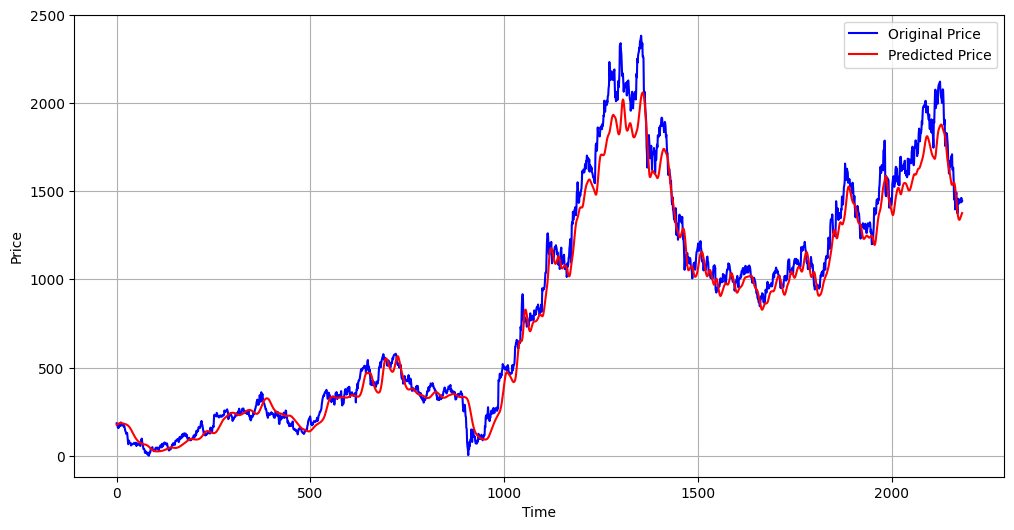

In [45]:
plt.figure(figsize = (12,6))
plt.plot(y_test, 'b', label = "Original Price")
plt.plot(y_pred, 'r', label = "Predicted Price")
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

# Model evaluation

Calculation of mean absolute error

In [46]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
mae_percentage = (mae / np.mean(y_test)) * 100
print("Mean absolute error on test set: {:.2f}%".format(mae_percentage))

Mean absolute error on test set: 8.56%


Calculation of R2 score

In [43]:
from sklearn.metrics import r2_score

# Actual values
actual = y_test

# Predicted values
predicted = y_pred

# Calculate the R2 score
r2 = r2_score(actual, predicted)

print("R2 score:", r2)

R2 score: 0.9693382124211163


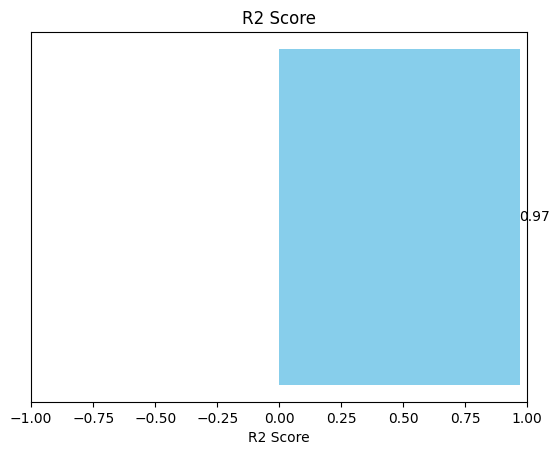

In [44]:
# Plotting the R2 score
fig, ax = plt.subplots()
ax.barh(0, r2, color='skyblue')
ax.set_xlim([-1, 1])
ax.set_yticks([])
ax.set_xlabel('R2 Score')
ax.set_title('R2 Score')

# Adding the R2 score value on the bar
ax.text(r2, 0, f'{r2:.2f}', va='center', color='black')

plt.show()

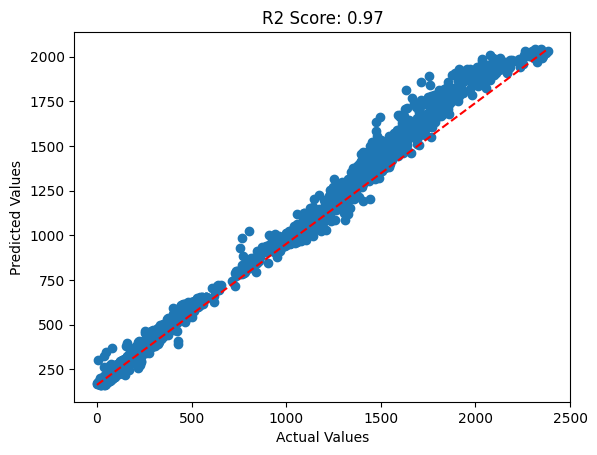

In [45]:
plt.scatter(actual, predicted)
plt.plot([min(actual), max(actual)], [min(predicted), max(predicted)], 'r--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'R2 Score: {r2:.2f}')
plt.show()